# Thermal Face Recognition — Occlusion Robustness Study (v4)
**Models:** ResNet50 · ConvNeXt-Tiny · EfficientNet-B0  
**Goal:** Compare accuracy on Clean (Non-Occluded) vs Occluded faces  
**Extras:** Grad-CAM visualizations + Precision/Recall/F1 metrics  
**v4 Changes:** ResNet50 — only layer4 unfrozen + lower LR + higher weight decay

## 1. Imports & Device Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import precision_score, recall_score, f1_score

# ── Device ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Data Transforms

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.Grayscale(num_output_channels=3),  # Thermal images have no color
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

## 3. Dataset Paths & Loaders

In [3]:
# ── Update these paths to match your machine ──
train_dir = r"D:\MyPC\Education\College\Project\Thermal_face_dataset\Train"
val_dir   = r"D:\MyPC\Education\College\Project\Thermal_face_dataset\Validate"
test_root = r"D:\MyPC\Education\College\Project\Thermal_face_dataset\Test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)

num_classes = len(train_dataset.classes)
print(f"Number of classes : {num_classes}")
print(f"Classes           : {train_dataset.classes}")
print(f"Train samples     : {len(train_dataset)}")
print(f"Val samples       : {len(val_dataset)}")

Number of classes : 8
Classes           : ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8']
Train samples     : 241
Val samples       : 49


## 4. Custom Test Dataset (Non-Occluded vs Occluded)

In [4]:
class ConditionDataset(Dataset):
    """Loads images from Test/<class>/<condition>/ folders."""

    def __init__(self, root_dir, condition, transform=None):
        self.samples   = []
        self.transform = transform
        self.classes   = sorted(os.listdir(root_dir))

        for label, class_name in enumerate(self.classes):
            condition_path = os.path.join(root_dir, class_name, condition)
            if os.path.exists(condition_path):
                for img in os.listdir(condition_path):
                    self.samples.append((os.path.join(condition_path, img), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


clean_dataset    = ConditionDataset(test_root, "Non-Occluded", val_transform)
occluded_dataset = ConditionDataset(test_root, "Occluded",     val_transform)

clean_loader    = DataLoader(clean_dataset,    batch_size=8, shuffle=False)
occluded_loader = DataLoader(occluded_dataset, batch_size=8, shuffle=False)

print(f"Clean (Non-Occluded) samples : {len(clean_dataset)}")
print(f"Occluded samples             : {len(occluded_dataset)}")

Clean (Non-Occluded) samples : 82
Occluded samples             : 84


## 5. Model Factory

In [5]:
def get_model(name):
    if name == "ResNet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Freeze everything, only unfreeze layer4 (tighter than before)
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters():
            param.requires_grad = True
        model.fc = nn.Sequential(
            nn.Linear(model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6),  # increased from 0.5
            nn.Linear(256, num_classes)
        )

    elif name == "ConvNeXt":
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
        #  FIX: Only unfreeze last block (tighter freezing vs v2)
        for param in model.features.parameters():
            param.requires_grad = False
        for param in model.features[-1].parameters():
            param.requires_grad = True
        #  FIX: Higher dropout (0.6) to reduce overfitting
        model.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(model.classifier[2].in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes)
        )

    elif name == "EfficientNet":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        for param in model.features.parameters():
            param.requires_grad = False
        for param in model.features[-1].parameters():
            param.requires_grad = True
        for param in model.features[-2].parameters():
            param.requires_grad = True
        model.classifier = nn.Sequential(
            nn.Linear(model.classifier[1].in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes)
        )

    return model.to(device)

## 6. Training Function (with Early Stopping + Weight Decay)

In [6]:
def train_model(model, train_loader, val_loader, epochs=6, lr=0.0003, weight_decay=1e-4, patience=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay  #  FIX: Penalizes large weights → reduces overfitting
    )

    best_val_acc = 0
    best_state   = None
    no_improve   = 0

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        correct, total, loss_sum = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            _, pred  = torch.max(outputs, 1)
            total    += labels.size(0)
            correct  += (pred == labels).sum().item()

        train_acc = 100 * correct / total

        # ── Validation ──
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, pred  = torch.max(outputs, 1)
                val_total   += labels.size(0)
                val_correct += (pred == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss={loss_sum:.4f} | Train={train_acc:.2f}% | Val={val_acc:.2f}%")

        #  FIX: Early stopping — save best weights, stop if no improvement
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"⏹ Early stopping at epoch {epoch+1} — best val acc: {best_val_acc:.2f}%")
                break

    # Always load best weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f" Loaded best weights (val acc: {best_val_acc:.2f}%)")

    return model

## 7. Evaluation Functions (Accuracy + Precision/Recall/F1)

In [7]:
def evaluate(model, loader):
    """Returns accuracy (float)."""
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, pred  = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total


def evaluate_full_metrics(model, loader):
    """Returns accuracy, precision, recall, F1 (all as %)."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc       = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    recall    = recall_score(all_labels,    all_preds, average='weighted', zero_division=0) * 100
    f1        = f1_score(all_labels,        all_preds, average='weighted', zero_division=0) * 100

    return acc, precision, recall, f1

## 8. Grad-CAM

In [8]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, image_path):
        """Returns (superimposed_rgb_array, predicted_class_idx)."""
        self.model.eval()

        image        = Image.open(image_path).convert("RGB")
        input_tensor = val_transform(image).unsqueeze(0).to(device)
        input_tensor.requires_grad_(True)

        # Forward
        output    = self.model(input_tensor)
        class_idx = output.argmax(dim=1).item()

        # Backward
        self.model.zero_grad()
        output[:, class_idx].backward(retain_graph=True)

        # Safety check
        if self.gradients is None:
            print(f" Gradients not captured — check target layer")
            return np.zeros((224, 224, 3), dtype=np.uint8), class_idx

        # Build heatmap
        pooled  = torch.mean(self.gradients, dim=[0, 2, 3], keepdim=True)
        heatmap = torch.mean(self.activations * pooled, dim=1).squeeze()
        heatmap = heatmap.cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= (heatmap.max() + 1e-8)

        # Superimpose on original image
        img_np  = np.array(image.resize((224, 224)))
        heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

        return overlay, class_idx


def get_gradcam_layer(model, name):
    """Returns the appropriate last feature layer per architecture."""
    if name == "ResNet50":
        return model.layer4[-1]
    elif name == "ConvNeXt":
        return model.features[-1]
    elif name == "EfficientNet":
        return model.features[-1]

## 9. Train All Models + Evaluate

In [9]:
results        = []
trained_models = {}  # Keep in memory for Grad-CAM
model_names    = ["ResNet50", "ConvNeXt", "EfficientNet"]

#  Per-model hyperparameters
epoch_map        = {"ResNet50": 10,   "ConvNeXt": 8,    "EfficientNet": 4   }
lr_map           = {"ResNet50": 1e-4, "ConvNeXt": 1e-4, "EfficientNet": 3e-4}
weight_decay_map = {"ResNet50": 1e-3, "ConvNeXt": 1e-3, "EfficientNet": 1e-4}
patience_map     = {"ResNet50": 3,    "ConvNeXt": 3,    "EfficientNet": 3   }

for name in model_names:
    print(f"\n{'='*55}")
    print(f"  Training {name}")
    print(f"  lr={lr_map[name]} | weight_decay={weight_decay_map[name]} | patience={patience_map[name]}")
    print(f"{'='*55}")

    model = get_model(name)
    model = train_model(
        model, train_loader, val_loader,
        epochs       = epoch_map[name],
        lr           = lr_map[name],
        weight_decay = weight_decay_map[name],
        patience     = patience_map[name]
    )

    clean_acc    = evaluate(model, clean_loader)
    occluded_acc = evaluate(model, occluded_loader)
    drop         = clean_acc - occluded_acc

    # Full metrics on clean test set
    acc, prec, rec, f1 = evaluate_full_metrics(model, clean_loader)

    print(f"\n{name} Results:")
    print(f"  Clean Acc    : {clean_acc:.2f}%")
    print(f"  Occluded Acc : {occluded_acc:.2f}%")
    print(f"  Drop         : {drop:.2f}%")
    print(f"  Precision    : {prec:.2f}%")
    print(f"  Recall       : {rec:.2f}%")
    print(f"  F1-Score     : {f1:.2f}%")

    torch.save(model.state_dict(), f"{name}.pth")

    results.append({
        "Model":             name,
        "Clean Acc (%)": clean_acc,
        "Occluded Acc (%)": occluded_acc,
        "Drop (%)": drop,
        "Precision (%)": prec,
        "Recall (%)": rec,
        "F1-Score (%)": f1
    })

    trained_models[name] = model
    torch.cuda.empty_cache()

# ── Results Table ──
df = pd.DataFrame(results)
print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)
print(df.to_string(index=False))
df.to_csv("model_comparison.csv", index=False)
print("\n Saved to model_comparison.csv")


  Training ResNet50
  lr=0.0001 | weight_decay=0.001 | patience=3
Epoch 01/10 | Loss=62.5422 | Train=26.14% | Val=16.33%
Epoch 02/10 | Loss=50.0676 | Train=63.49% | Val=59.18%
Epoch 03/10 | Loss=29.6970 | Train=83.40% | Val=91.84%
Epoch 04/10 | Loss=13.2212 | Train=95.85% | Val=95.92%
Epoch 05/10 | Loss=7.6698 | Train=97.10% | Val=97.96%
Epoch 06/10 | Loss=4.7590 | Train=97.51% | Val=95.92%
Epoch 07/10 | Loss=3.8629 | Train=99.17% | Val=100.00%
Epoch 08/10 | Loss=2.4966 | Train=100.00% | Val=97.96%
Epoch 09/10 | Loss=3.8449 | Train=99.17% | Val=93.88%
Epoch 10/10 | Loss=2.0302 | Train=100.00% | Val=95.92%
⏹ Early stopping at epoch 10 — best val acc: 100.00%
 Loaded best weights (val acc: 100.00%)

ResNet50 Results:
  Clean Acc    : 97.56%
  Occluded Acc : 91.67%
  Drop         : 5.89%
  Precision    : 97.75%
  Recall       : 97.56%
  F1-Score     : 97.50%

  Training ConvNeXt
  lr=0.0001 | weight_decay=0.001 | patience=3
Epoch 01/8 | Loss=61.5827 | Train=39.42% | Val=77.55%
Epoch 02/8

## 10. Results Bar Chart

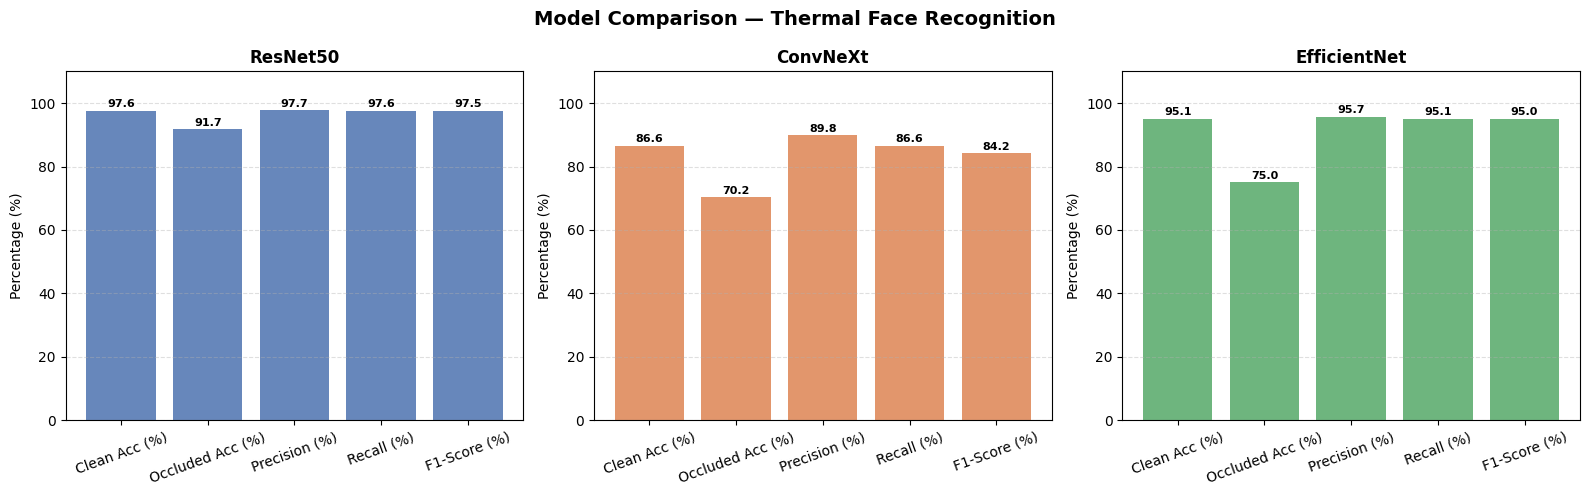

 Saved to model_comparison.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison — Thermal Face Recognition", fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868']

for i, row in df.iterrows():
    ax      = axes[i]
    metrics = ['Clean Acc (%)', 'Occluded Acc (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
    values  = [row[m] for m in metrics]
    bars    = ax.bar(metrics, values, color=colors[i], alpha=0.85)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_title(row['Model'], fontsize=12, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to model_comparison.png")

## 11. Build Grad-CAM Objects

In [11]:
gradcam_objects = {}
for name, model in trained_models.items():
    target_layer = get_gradcam_layer(model, name)
    gradcam_objects[name] = GradCAM(model, target_layer)

print(" Grad-CAM objects ready for:", list(gradcam_objects.keys()))

 Grad-CAM objects ready for: ['ResNet50', 'ConvNeXt', 'EfficientNet']


## 12. Grad-CAM — Side-by-Side All Models
> Update `test_image_path` to any image from your test set.

C:\Users\aalex\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torch\nn\modules\module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


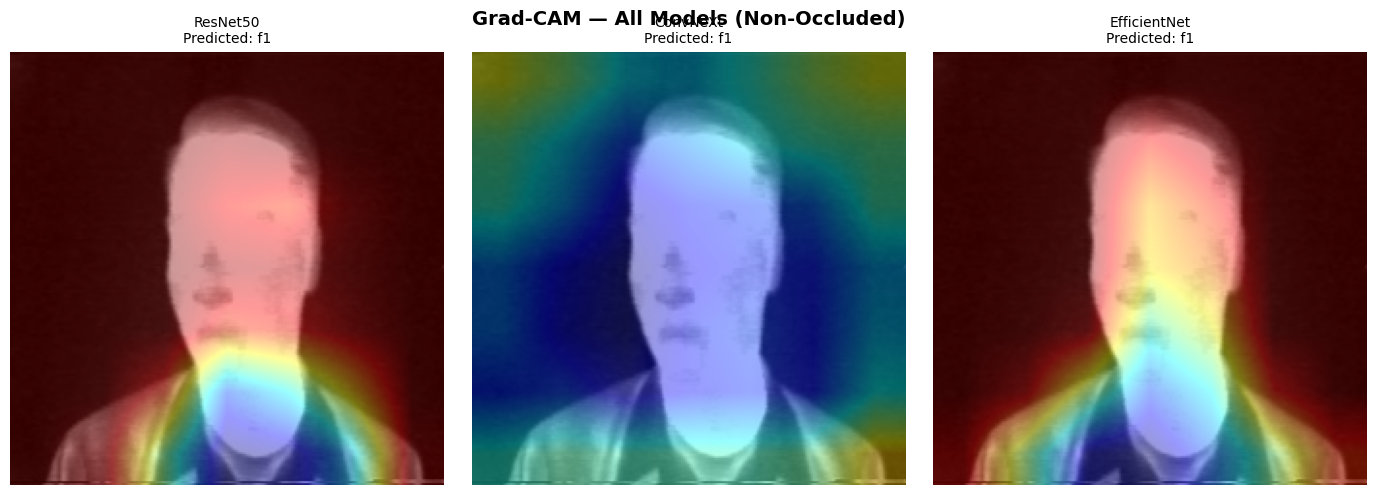

 Saved to gradcam_all_models.png


In [12]:
# ── Update this path ──
test_image_path = r"D:\MyPC\Education\College\Project\Thermal_face_dataset\Test\f1\Non-Occluded\0171.jpg"

class_names = train_dataset.classes

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Grad-CAM — All Models (Non-Occluded)", fontsize=14, fontweight='bold')

for ax, (name, gradcam) in zip(axes, gradcam_objects.items()):
    overlay, pred_idx = gradcam.generate(test_image_path)
    pred_label = class_names[pred_idx]
    ax.imshow(overlay)
    ax.axis("off")
    ax.set_title(f"{name}\nPredicted: {pred_label}", fontsize=10)

plt.tight_layout()
plt.savefig("gradcam_all_models.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to gradcam_all_models.png")

## 13. Grad-CAM — Clean vs Occluded (ConvNeXt)
> Shows how ConvNeXt attention shifts under occlusion.

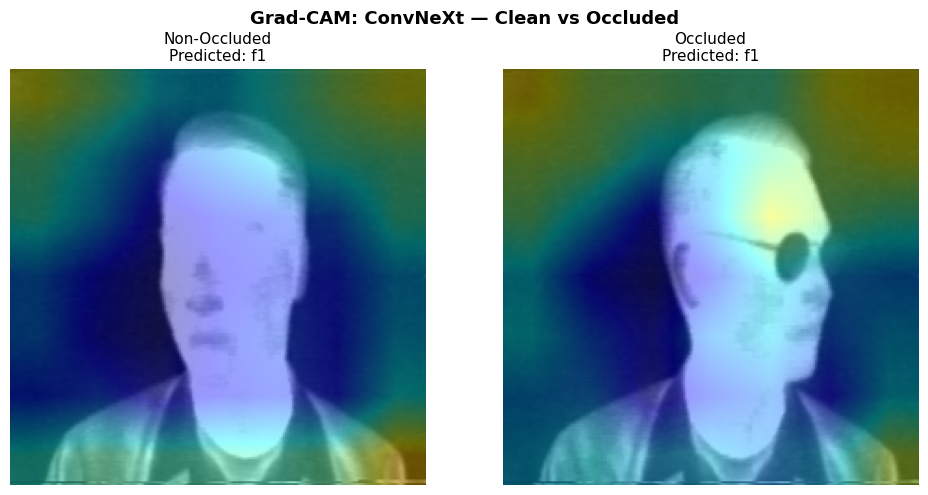

 Saved to gradcam_convnext_clean_vs_occluded.png


In [13]:
# ── Update these paths ──
clean_image_path    = r"D:\MyPC\Education\College\Project\Thermal_face_dataset\Test\f1\Non-Occluded\0171.jpg"
occluded_image_path = r"D:\MyPC\Education\College\Project\Thermal_face_dataset\Test\f1\Occluded\0449.jpg"

focus_model  = "ConvNeXt"   # ← Your main model
gradcam_focus = gradcam_objects[focus_model]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(f"Grad-CAM: {focus_model} — Clean vs Occluded", fontsize=13, fontweight='bold')

for ax, (img_path, title) in zip(axes, [
    (clean_image_path,    "Non-Occluded"),
    (occluded_image_path, "Occluded")
]):
    overlay, pred_idx = gradcam_focus.generate(img_path)
    pred_label = class_names[pred_idx]
    ax.imshow(overlay)
    ax.axis("off")
    ax.set_title(f"{title}\nPredicted: {pred_label}", fontsize=11)

plt.tight_layout()
plt.savefig("gradcam_convnext_clean_vs_occluded.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved to gradcam_convnext_clean_vs_occluded.png")